# BATCH3 — 원본 데이터 직접 확인

`2018-04-12_batchdata_updated_struct_errorcorrect.mat`을 읽습니다. 프로젝트 `.venv` 커널에서 위에서부터 전체 실행하세요.

이 파일은 CSV가 아니라 MATLAB v7.3 / HDF5 파일입니다. `h5py.File`로 열면 파일 구조에 접근할 수 있고, `[()]`로 요청한 배열만 메모리에 읽습니다. `batch`의 각 필드는 셀 데이터 자체 대신 HDF5 **객체 참조**를 담고 있어 `file[reference]`로 따라가야 합니다.

아래는 공통 로더 뒤에 숨기지 않고 그 과정을 직접 보여주는 학습·점검용 코드입니다. 반복 EDA에는 `src/load_data.py`와 `00_data_inspection.ipynb`를 사용합니다. 원본 파일은 읽기 모드로만 엽니다.

In [1]:
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [cwd, *cwd.parents]
                     if (p / "src/load_data.py").is_file()
                     and (p / "requirements.txt").is_file()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("프로젝트 디렉토리에서 실행하세요.")

BATCH_NAME = "batch3"
MAT_PATH = PROJECT_ROOT / "data/raw/2018-04-12_batchdata_updated_struct_errorcorrect.mat"
CELL_ID = 0          # 파일 내 셀 위치 (0부터 시작)
CYCLE_INDEX = 1      # 상세 cycle의 저장 위치 (0부터 시작)
print("File:", MAT_PATH.name)
print("Size (GiB):", round(MAT_PATH.stat().st_size / 1024**3, 2))

File: 2018-04-12_batchdata_updated_struct_errorcorrect.mat
Size (GiB): 3.01


## 1. HDF5 구조와 참조 확인

`batch`의 필드 shape은 셀 항목 수를 나타냅니다. `#refs#`에는 참조 대상이 저장돼 있습니다. 모든 참조 대상을 순회하거나 전체 파일을 Python 객체로 변환하지 않습니다.

In [2]:
with h5py.File(MAT_PATH, "r") as file:
    print("Root keys:", list(file.keys()))
    batch = file["batch"]
    display(pd.DataFrame([
        {"field": key, "shape": value.shape, "dtype": str(value.dtype),
         "is_reference": h5py.check_dtype(ref=value.dtype) is not None}
        for key, value in batch.items()
    ]))
    summary_refs = batch["summary"][()].reshape(-1, order="F")
    print("Cell count:", len(summary_refs))
    ref = summary_refs[CELL_ID]
    print("Reference type:", type(ref).__name__)
    print("Resolved summary group:", file[ref].name)
    print("Summary fields:", list(file[ref].keys()))
# with 블록을 벗어나면 파일이 닫힙니다. 다음 셀에서는 다시 엽니다.

Root keys: ['#refs#', '#subsystem#', 'batch', 'batch_date']


,field,shape,dtype,is_reference
0,Vdlin,"(46, 1)",object,True
1,barcode,"(46, 1)",object,True
2,channel_id,"(46, 1)",object,True
3,cycle_life,"(46, 1)",object,True
4,cycles,"(46, 1)",object,True
5,policy,"(46, 1)",object,True
6,policy_readable,"(46, 1)",object,True
7,summary,"(46, 1)",object,True


Cell count: 46
Reference type: Reference


Resolved summary group:

 /#refs#/#d/cBp
Summary fields: ['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


## 2. 한 셀의 메타데이터와 summary 읽기

문자열은 MATLAB 문자 코드 배열에서 복원합니다. `summary.cycle`을 그대로 사용하며 새 번호를 만들지 않습니다. summary의 필드 길이가 다르면 오류로 표시합니다. `barcode`/`channel_id`는 원본 숫자 표현만 보존하고 물리 셀 식별자로 해석하지 않습니다.

In [3]:
def cell_field(file, field, cell_id):
    refs = file["batch"][field][()].reshape(-1, order="F")
    return file[refs[cell_id]]

def matlab_text(dataset):
    return "".join(chr(int(v)) for v in dataset[()].reshape(-1, order="F"))

with h5py.File(MAT_PATH, "r") as file:
    life_array = cell_field(file, "cycle_life", CELL_ID)[()].reshape(-1)
    assert life_array.size == 1
    cell_info = {
        "batch": BATCH_NAME, "cell_id": CELL_ID,
        "cycle_life": float(life_array[0]),
        "policy": matlab_text(cell_field(file, "policy_readable", CELL_ID)),
        "barcode_raw": cell_field(file, "barcode", CELL_ID)[()].reshape(-1).tolist(),
        "channel_id_raw": cell_field(file, "channel_id", CELL_ID)[()].reshape(-1).tolist(),
    }
    group = cell_field(file, "summary", CELL_ID)
    field_shapes = {key: ds.shape for key, ds in group.items()}
    columns = {key: ds[()].reshape(-1) for key, ds in group.items()}
    assert len({len(array) for array in columns.values()}) == 1
    cell_summary = pd.DataFrame(columns)

print("Cell metadata:", cell_info)
print("Raw summary shapes:", field_shapes)
print("Summary table:", cell_summary.shape)
display(cell_summary.head(12))
display(cell_summary.tail(3))
display(cell_summary.describe())
display(pd.DataFrame({"nonfinite": (~np.isfinite(cell_summary)).sum(),
                      "zeros": cell_summary.eq(0).sum()}))

Cell metadata: {'batch': 'batch3', 'cell_id': 0, 'cycle_life': 1009.0, 'policy': '5C(67%)-4C-newstructure', 'barcode_raw': [3707764736, 2, 1, 1, 1, 1], 'channel_id_raw': [3707764736, 2, 1, 1, 47, 1]}
Raw summary shapes: {'IR': (1, 1008), 'QCharge': (1, 1008), 'QDischarge': (1, 1008), 'Tavg': (1, 1008), 'Tmax': (1, 1008), 'Tmin': (1, 1008), 'chargetime': (1, 1008), 'cycle': (1, 1008)}
Summary table: (1008, 8)


,IR,QCharge,QDischarge,Tavg,Tmax,Tmin,chargetime,cycle
0,0.015435,1.066090,1.066573,32.149495,33.433834,30.830272,10.043408,1.0
1,0.015399,1.066964,1.067455,32.106606,33.403964,30.779943,10.043255,2.0
2,0.015365,1.067611,1.068285,32.088511,33.325268,30.824746,10.042333,3.0
3,0.015326,1.068164,1.068708,32.086306,33.304202,30.804544,10.052677,4.0
4,0.015309,1.068695,1.069094,32.041147,33.257191,30.791834,10.042382,5.0
5,0.015302,1.068945,1.069415,32.014179,33.294998,30.691322,10.042008,6.0
6,0.015286,1.069392,1.069730,32.047485,33.306644,30.734112,10.041378,7.0
7,0.015268,1.069520,1.069987,32.070644,33.364697,30.738612,10.042217,8.0
8,0.015264,1.069904,1.070237,32.081592,33.365837,30.760095,10.044023,9.0
9,0.015250,1.070021,1.070419,32.076224,33.608757,30.711397,10.042508,10.0


,IR,QCharge,QDischarge,Tavg,Tmax,Tmin,chargetime,cycle
1005,0.017458,0.883688,0.882473,33.041687,34.779043,31.382666,14.906802,1006.0
1006,0.017626,0.882362,0.881284,33.044793,34.766421,31.437250,15.574885,1007.0
1007,0.017773,0.881636,0.880433,33.001542,34.763348,31.365874,16.364433,1008.0


,IR,QCharge,QDischarge,Tavg,Tmax,Tmin,chargetime,cycle
count,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000,1008.000000
mean,0.015301,1.036917,1.037084,33.101531,34.745492,31.622150,10.155437,504.500000
std,0.000270,0.039960,0.040293,0.446920,0.547708,0.409854,0.503002,291.128837
min,0.015158,0.881636,0.880433,31.998854,33.257191,30.613684,10.040100,1.000000
25%,0.015211,1.028539,1.028695,32.948467,34.620374,31.390356,10.042016,252.750000
50%,0.015235,1.050701,1.050987,33.140508,34.817210,31.672187,10.042997,504.500000
75%,0.015274,1.063841,1.064130,33.455050,35.178255,31.958213,10.044003,756.250000
max,0.017773,1.070986,1.071371,33.888030,35.640464,32.458736,16.364433,1008.000000


,nonfinite,zeros
IR,0,0
QCharge,0,0
QDischarge,0,0
Tavg,0,0
Tmax,0,0
Tmin,0,0
chargetime,0,0
cycle,0,0


## 3. 선택한 셀의 개요

원본 그대로 표시합니다. 초기 0값이나 수명과 기록 길이 차이는 원인을 확인한 뒤 처리합니다. 수명 종료 기준선은 아직 정의하지 않습니다.

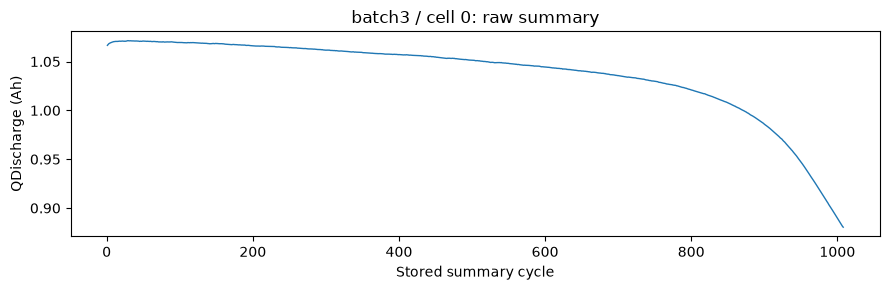

In [4]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(cell_summary["cycle"], cell_summary["QDischarge"], linewidth=1)
ax.set(title=f"{BATCH_NAME} / cell {CELL_ID}: raw summary",
       xlabel="Stored summary cycle", ylabel="QDischarge (Ah)")
fig.tight_layout()
plt.show()

## 4. 상세 cycle 한 개만 읽기

`cycles.Qdlin`도 cycle별 객체 참조 배열입니다. 참조 배열의 `CYCLE_INDEX` 위치를 따라가 용량 곡선만 읽습니다. `Vdlin`은 해당 셀의 전압 격자입니다.

이 단계는 **저장 위치 확인**이며 실험 cycle 번호와의 대응을 확정하지 않습니다. summary 행 수와 cycles 길이가 같아도 그 사실만으로 대응이 증명되지는 않습니다.

In [5]:
with h5py.File(MAT_PATH, "r") as file:
    cycles_group = cell_field(file, "cycles", CELL_ID)
    display(pd.DataFrame([
        {"field": key, "reference_shape": ds.shape}
        for key, ds in cycles_group.items()
    ]))
    qd_refs = cycles_group["Qdlin"][()].reshape(-1, order="F")
    if not 0 <= CYCLE_INDEX < len(qd_refs):
        raise IndexError(f"CYCLE_INDEX must be within 0..{len(qd_refs)-1}")
    qdlin = file[qd_refs[CYCLE_INDEX]][()].reshape(-1)
    voltage = cell_field(file, "Vdlin", CELL_ID)[()].reshape(-1)

assert len(qdlin) == len(voltage)
print("Detailed storage index:", CYCLE_INDEX)
print("Qdlin / Vdlin shapes:", qdlin.shape, voltage.shape)
print("Finite arrays:", np.isfinite(qdlin).all(), np.isfinite(voltage).all())
display(pd.DataFrame({"Vdlin": voltage, "Qdlin": qdlin}).head())

,field,reference_shape
0,I,"(1008, 1)"
1,Qc,"(1008, 1)"
2,Qd,"(1008, 1)"
3,Qdlin,"(1008, 1)"
4,T,"(1008, 1)"
5,Tdlin,"(1008, 1)"
6,V,"(1008, 1)"
7,discharge_dQdV,"(1008, 1)"
8,t,"(1008, 1)"


Detailed storage index: 1
Qdlin / Vdlin shapes: (1000,) (1000,)
Finite arrays: True True


,Vdlin,Qdlin
0,3.500000,-0.000172
1,3.498498,-0.000144
2,3.496997,-0.000116
3,3.495495,-0.000090
4,3.493994,-0.000064


## 5. 이 Batch의 전체 셀 요약 목록

전체 셀의 수명·충전 정책·summary 길이만 읽습니다. 모든 상세 cycle 시계열을 로드하지 않습니다. 메모리에 남는 결과는 아래의 작은 표와 선택한 셀의 summary·곡선뿐입니다.

In [6]:
rows = []
with h5py.File(MAT_PATH, "r") as file:
    n_cells = file["batch"]["cycle_life"].size
    for cell_id in range(n_cells):
        life = cell_field(file, "cycle_life", cell_id)[()].reshape(-1)
        assert life.size == 1
        cycle = cell_field(file, "summary", cell_id)["cycle"][()].reshape(-1)
        rows.append({
            "batch": BATCH_NAME, "cell_id": cell_id,
            "cycle_life": float(life[0]),
            "charging_policy": matlab_text(cell_field(file, "policy_readable", cell_id)),
            "summary_rows": len(cycle),
            "first_stored_cycle": cycle[0] if len(cycle) else np.nan,
            "last_stored_cycle": cycle[-1] if len(cycle) else np.nan,
        })
cell_inventory = pd.DataFrame(rows)
with pd.option_context("display.max_rows", 60):
    display(cell_inventory)
print("Missing cycle_life:", cell_inventory["cycle_life"].isna().sum())

,batch,cell_id,cycle_life,charging_policy,summary_rows,first_stored_cycle,last_stored_cycle
0,batch3,0,1009.0,5C(67%)-4C-newstructure,1008,1.0,1008.0
1,batch3,1,1063.0,5.3C(54%)-4C-newstructure,1062,1.0,1062.0
2,batch3,2,1267.0,5.6C(19%)-4.6C-newstructure,1266,1.0,1266.0
3,batch3,3,1115.0,5.6C(36%)-4.3C-newstructure,1114,1.0,1114.0
4,batch3,4,1048.0,5.6C(19%)-4.6C-newstructure,1047,1.0,1047.0
5,batch3,5,828.0,5.6C(36%)-4.3C-newstructure,827,1.0,827.0
6,batch3,6,667.0,3.7C(31%)-5.9C-newstructure,666,1.0,666.0
7,batch3,7,1836.0,4.8C(80%)-4.8C-newstructure,1835,1.0,1835.0
8,batch3,8,828.0,5C(67%)-4C-newstructure,827,1.0,827.0
9,batch3,9,1039.0,5.3C(54%)-4C-newstructure,1038,1.0,1038.0


Missing cycle_life: 2


## 직접 바꿔볼 조건

상단의 `CELL_ID`, `CYCLE_INDEX`를 바꾸고 위에서부터 다시 실행하면 다른 셀과 상세 곡선을 확인할 수 있습니다. 파일 경로는 이 Batch로 고정돼 있습니다.

관찰과 추가 질문을 이 아래에 기록하세요. Batch 간 비교와 전처리는 공통 탐색 노트북에서 이어갑니다.